# CSCE 676 — Data Mining — Project Checkpoint 2  
## Research Question Formation for Biomedical Representation Analysis on PubMed 200K RCT


### Project theme
The broader project studies the following singular question:

> **How does the choice of text representation affect the organization and retrieval of biomedical knowledge?**


# (A) Project Scope Recap from Checkpoint 1

### Selected Dataset

The project uses the **PubMed 200k RCT dataset**, a large collection of biomedical research abstracts derived from PubMed.  
Each abstract is segmented into individual sentences, and every sentence is annotated with its **rhetorical role** in the scientific article. The possible labels include:

- **BACKGROUND**
- **OBJECTIVE**
- **METHODS**
- **RESULTS**
- **CONCLUSIONS**

This structure makes the dataset particularly useful for studying how biomedical knowledge is communicated within scientific literature. Because each sentence is labeled with its functional role in a research abstract, the dataset supports analysis of both **textual content** and **structural patterns** in scientific writing.

The corpus contains approximately **2.27 million sentences** across the training, validation, and test splits, making it large enough to represent real-world biomedical literature while still being computationally manageable for experimentation.


### Key Findings from Checkpoint 1 Exploratory Data Analysis

Checkpoint 1 focused on understanding the dataset through **exploratory data analysis (EDA)** and assessing whether it is suitable for data mining techniques.

Several observations from the EDA influenced the direction of this project:

**1. Dataset Scale**

The dataset contains millions of sentences, providing a sufficiently large corpus for applying machine learning and data mining techniques. This scale makes the dataset representative of real biomedical literature and allows meaningful analysis of patterns across many documents.

**2. Class Imbalance**

The distribution of sentence labels is highly imbalanced.  
Labels such as **METHODS** and **RESULTS** occur much more frequently than labels such as **OBJECTIVE**. This imbalance reflects the natural structure of scientific papers, where methodological and experimental descriptions dominate the text.

Understanding this imbalance is important because it affects clustering behavior, retrieval results, and evaluation metrics.

**3. Variation in Sentence Length**

Sentence lengths vary significantly across the dataset. Some sentences are short factual statements, while others are longer technical descriptions of experimental procedures or findings. This variation suggests that different sentence types may contain different levels of semantic information.

**4. Sparse Lexical Representation**

Using TF-IDF to represent sentences revealed that the feature space is extremely sparse (approximately **99.78% zero values**). This sparsity is typical in specialized domains like biomedical literature, where terminology is highly specific and many words appear infrequently.

This observation motivated exploring **semantic embeddings** in addition to lexical representations.

**5. Initial Clustering Experiment**

A preliminary clustering experiment was performed using **TF-IDF features with MiniBatchKMeans**.  
The resulting **silhouette score (~0.01)** was very low, indicating that simple lexical clustering does not strongly separate meaningful groups within the data.

This result suggests that:

- lexical similarity alone may not capture deeper relationships between biomedical sentences
- more advanced representations or alternative data mining techniques may be necessary to uncover structure in the dataset


### Motivation for Expanding in Checkpoint 2

The EDA in Checkpoint 1 revealed key patterns in the PubMed dataset:

- clear **rhetorical structure** (BACKGROUND, METHODS, RESULTS, etc.)
- **differences in vocabulary and sentence length** across labels
- a mix of **terminology-heavy and semantically varied language**

These observations suggest that meaningful structure exists.

Based on this, Checkpoint 2 focuses on studying how different representations capture this structure using data mining techniques, including:

- **clustering** to analyze sentence organization  
- **label-aware analysis** to compare behavior across rhetorical roles  
- **semantic or thematic coherence checks**  



### Project Scope

Based on the dataset and exploratory analysis conducted in Checkpoint 1, the scope of this project is summarized below.

**1) Dataset**

- **PubMed 200k RCT Dataset**
- Contains approximately **2.27 million sentences** extracted from biomedical research abstracts.
- Each sentence is annotated with a **rhetorical role label** (BACKGROUND, OBJECTIVE, METHODS, RESULTS, CONCLUSIONS).
- The dataset is well suited for analyzing the **structure and semantics of biomedical scientific writing**.

**2) Course Techniques**

The project applies several techniques covered in the course:

-**TF-IDF Vectorization**

- **Clustering**  
  MiniBatchKMeans will be used to group biomedical sentences based on lexical or semantic similarity.

- **Similarity Analysis**

These techniques aim to uncover structural patterns and relationships in biomedical text.

**3) External (Beyond-Course) Techniques**

To extend the analysis beyond the techniques covered in class, the project will also explore:

- **Semantic Sentence Embeddings**  
- **Hybrid Representation Analysis**

- **Topic Modeling (Latent Dirichlet Allocation – LDA)**  
  Topic modeling will be applied to discover **latent thematic structures** across biomedical abstracts.

This technique allows analysis of high-level thematic organization in biomedical literature that may not be captured through clustering or graph analysis alone.

In [4]:
# (C) Imports and reproducibility settings

import os
import re
import math
import json
import random
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# (D) Data Download from GitHub + Parsing Utilities

The dataset is loaded **from GitHub**.

The code below downloads the three standard PubMed RCT splits directly from the public repository when needed:
- `train.txt`
- `dev.txt`
- `test.txt`


In [5]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

DATA_DIR = Path("data_pubmed_rct")
DATA_DIR.mkdir(exist_ok=True)

BASE_URL_TXT = (
    "https://raw.githubusercontent.com/Franck-Dernoncourt/pubmed-rct/master/"
    "PubMed_200k_RCT_numbers_replaced_with_at_sign"
)

BASE_URL_ZIP = (
    "https://github.com/Franck-Dernoncourt/pubmed-rct/raw/master/"
    "PubMed_200k_RCT_numbers_replaced_with_at_sign"
)

FILE_URLS = {
    "train_zip": f"{BASE_URL_ZIP}/train.zip",
    "dev": f"{BASE_URL_TXT}/dev.txt",
    "test": f"{BASE_URL_TXT}/test.txt",
}

LOCAL_PATHS = {
    "train_zip": DATA_DIR / "train.zip",
    "train": DATA_DIR / "train.txt",
    "dev": DATA_DIR / "dev.txt",
    "test": DATA_DIR / "test.txt",
}

def download_file(url: str, destination: Path) -> None:
    if destination.exists():
        print(f"{destination.name} already exists. Skipping.")
        return

    print(f"Downloading {destination.name} ...")
    urlretrieve(url, destination)
    print(f"Saved to {destination}")

# Download dev/test text files directly
download_file(FILE_URLS["dev"], LOCAL_PATHS["dev"])
download_file(FILE_URLS["test"], LOCAL_PATHS["test"])

# Download and extract training split from zip archive
if not LOCAL_PATHS["train"].exists():
    download_file(FILE_URLS["train_zip"], LOCAL_PATHS["train_zip"])

    print("Extracting train.zip ...")
    with zipfile.ZipFile(LOCAL_PATHS["train_zip"], "r") as zf:
        members = zf.namelist()
        print("Zip contents:", members)
        zf.extractall(DATA_DIR)

    if LOCAL_PATHS["train"].exists():
        print(f"Extracted {LOCAL_PATHS['train']}")
    else:
        raise FileNotFoundError("train.zip was extracted, but train.txt was not found.")
else:
    print("train.txt already exists. Skipping zip download/extraction.")

assert LOCAL_PATHS["train"].exists(), "train.txt is missing"
assert LOCAL_PATHS["dev"].exists(), "dev.txt is missing"
assert LOCAL_PATHS["test"].exists(), "test.txt is missing"

print("\nAll dataset files are ready:")
for split in ["train", "dev", "test"]:
    print(f"{split}: {LOCAL_PATHS[split]}")

Saved to data_pubmed_rct/dev.txt
Saved to data_pubmed_rct/test.txt
Saved to data_pubmed_rct/train.zip
Extracting train.zip ...
Zip contents: ['train.txt']
Extracted data_pubmed_rct/train.txt

All dataset files are ready:
train: data_pubmed_rct/train.txt
dev: data_pubmed_rct/dev.txt
test: data_pubmed_rct/test.txt


In [6]:
def parse_pubmed_rct(path: Path) -> pd.DataFrame:
    ## Parsing PubMed RCT text files into a sentence-level DataFrame
    rows = []
    abstract_id = -1
    sentence_id = 0

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()

            if not line:
                continue

            if line.startswith("###"):
                abstract_id += 1
                sentence_id = 0
                continue

            # Expected format: LABEL<TAB>sentence text
            if "\t" not in line:
                continue

            label, sentence = line.split("\t", 1)
            sentence = sentence.strip()

            rows.append(
                {
                    "abstract_id": abstract_id,
                    "sentence_id": sentence_id,
                    "label": label,
                    "text": sentence,
                    "n_chars": len(sentence),
                    "n_words": len(sentence.split()),
                }
            )
            sentence_id += 1

    df = pd.DataFrame(rows)
    return df

train_df = parse_pubmed_rct(LOCAL_PATHS["train"])
dev_df = parse_pubmed_rct(LOCAL_PATHS["dev"])
test_df = parse_pubmed_rct(LOCAL_PATHS["test"])

print(train_df.shape, dev_df.shape, test_df.shape)
train_df.head()


(2211861, 6) (28932, 6) (29493, 6)


,abstract_id,sentence_id,label,text,n_chars,n_words
0,0,0,BACKGROUND,The emergence of HIV as a chronic condition me...,226,36
1,0,1,BACKGROUND,This paper describes the design and evaluation...,160,27
2,0,2,METHODS,This study is designed as a randomised control...,176,31
3,0,3,METHODS,The intervention group will participate in the...,90,15
4,0,4,METHODS,The program is based on self-efficacy theory a...,195,31


### Tests for non-trivial parsing behavior

The tests below validate:
- sentence order resetting at new abstracts,
- required columns existing,
- non-negative lengths,
- and the presence of multiple rhetorical labels.


In [7]:
required_columns = {"abstract_id", "sentence_id", "label", "text", "n_chars", "n_words"}

assert required_columns.issubset(train_df.columns), "Parsed dataframe is missing required columns."
assert train_df["sentence_id"].min() == 0, "Sentence positions should start at 0."
assert (train_df["n_words"] >= 1).all(), "Every parsed sentence should have at least one token."
assert train_df["label"].nunique() >= 5, "Expected all major rhetorical labels to be present."

first_positions = train_df.groupby("abstract_id")["sentence_id"].min()
assert (first_positions == 0).all(), "Each abstract should restart sentence numbering at 0."

print("Parser tests passed.")


Parser tests passed.


### Design choice: preserve sentence-level granularity
I keep the data at the **sentence level** because:
- the dataset labels are sentence-level,
- representation quality can be evaluated against sentence labels,
- and the later search interface can rank fine-grained biomedical statements rather than only entire documents.


In [8]:
# Combine splits only where useful for global EDA; retain split identity for transparency.
for name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    df["split"] = name

all_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
print(all_df.shape)
all_df.sample(5, random_state=RANDOM_STATE)


(2270286, 7)


,abstract_id,sentence_id,label,text,n_chars,n_words,split
295272,25416,19,CONCLUSIONS,Calcium channel blockers had no influence on t...,89,15,train
1939239,167213,7,CONCLUSIONS,Objective diagnostic tests are of limited addi...,62,9,train
1952327,168361,6,METHODS,Post hoc analyses examined the association bet...,101,17,train
1945997,167805,8,RESULTS,No serious adverse events were reported .,41,7,train
2115977,182394,5,METHODS,Successful pregnancy ( live birth ) .,37,7,train


# (E) Data Quality Checks and Additional EDA for RQ Formation

Checkpoint 2 - **additional EDA** to discover research questions.


In [9]:
# Basic quality checks
quality_summary = pd.DataFrame(
    {
        "rows": [len(all_df)],
        "unique_abstracts": [all_df["abstract_id"].nunique()],
        "unique_labels": [all_df["label"].nunique()],
        "missing_text_rows": [all_df["text"].isna().sum()],
        "duplicate_sentence_rows": [all_df.duplicated(subset=["abstract_id", "sentence_id", "text"]).sum()],
    }
)
quality_summary


,rows,unique_abstracts,unique_labels,missing_text_rows,duplicate_sentence_rows
0,2270286,190654,5,0,0


I perfomed this above basic quality check because before proposing research questions, I need to confirm that the dataset is not compromised by obvious issues such as:
- missing text,
- malformed parsing,
- or duplicated sentence rows.


In [10]:
label_counts = all_df["label"].value_counts().sort_values(ascending=False)
label_counts


,count
label,
RESULTS,786524
METHODS,741896
CONCLUSIONS,348536
BACKGROUND,201927
OBJECTIVE,191403


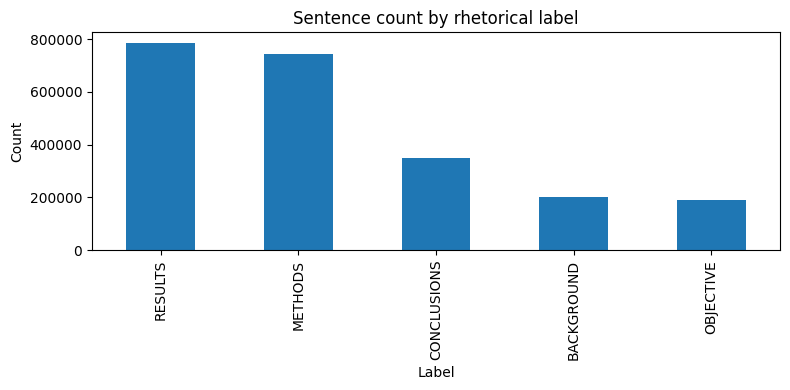

In [11]:
plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Sentence count by rhetorical label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### EDA interpretation: label imbalance
The label distribution is clearly uneven.  
This matters because any representation or clustering method can be biased toward the most common rhetorical roles.

This motivates a question that if one method appears better overall, is that because it genuinely captures structure, or because it performs well mainly on dominant labels such as METHODS and RESULTS?


In [12]:
abstract_lengths = (
    all_df.groupby(["split", "abstract_id"])["sentence_id"].max().add(1).rename("n_sentences").reset_index()
)
abstract_lengths["n_sentences"].describe()


,n_sentences
count,195654.000000
mean,11.603576
std,3.079627
min,3.000000
25%,10.000000
50%,11.000000
75%,13.000000
max,51.000000


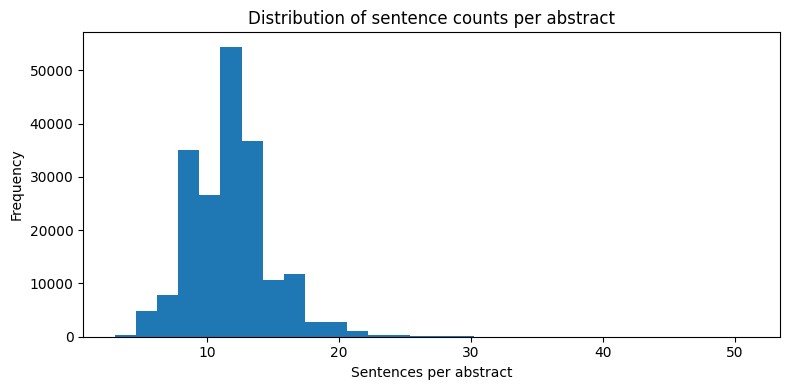

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(abstract_lengths["n_sentences"], bins=30)
plt.title("Distribution of sentence counts per abstract")
plt.xlabel("Sentences per abstract")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### EDA interpretation: abstract structure exists
Abstracts are not single independent sentences.They are short, structured sequences.  
That makes the dataset richer than a generic text corpus and supports questions about:
- rhetorical organization,
- representation sensitivity by section,
- and eventual retrieval/display grouped by abstract context.


In [14]:
length_by_label = (
    all_df.groupby("label")["n_words"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)
length_by_label


,count,mean,median,std,min,max
label,,,,,,
RESULTS,786524,29.585142,26.0,17.888442,1,338
OBJECTIVE,191403,27.133383,25.0,11.217434,1,167
METHODS,741896,24.816124,22.0,15.094091,1,250
CONCLUSIONS,348536,23.051639,22.0,9.536383,1,231
BACKGROUND,201927,22.971217,22.0,10.933745,1,159


<Figure size 800x400 with 0 Axes>

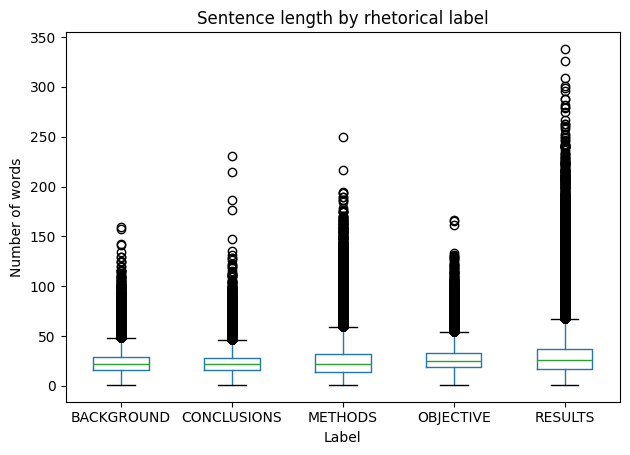

In [15]:
plt.figure(figsize=(8, 4))
all_df.boxplot(column="n_words", by="label", grid=False)
plt.title("Sentence length by rhetorical label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Number of words")
plt.tight_layout()
plt.show()


### EDA interpretation: sentence length heterogeneity
Sentence lengths vary substantially across rhetorical roles.  
This suggests that the "best" representation may not be universal:

- shorter, terminology-heavy sentences may favor lexical methods,
- while longer contextual sentences may benefit more from semantic methods.

That is the core intuition behind a label-sensitive representation comparison.


In [16]:
# Examine first-label and last-label tendencies within abstracts.
first_labels = all_df.sort_values(["abstract_id", "sentence_id"]).groupby("abstract_id").first()["label"].value_counts()
last_labels = all_df.sort_values(["abstract_id", "sentence_id"]).groupby("abstract_id").last()["label"].value_counts()

order_df = pd.DataFrame({"first_label_count": first_labels, "last_label_count": last_labels}).fillna(0).astype(int)
order_df


,first_label_count,last_label_count
label,,
BACKGROUND,80308,11169
CONCLUSIONS,118,176944
METHODS,1298,1199
OBJECTIVE,108927,6
RESULTS,3,1336


### EDA interpretation: rhetorical ordering is structured
The first and last sentence labels are not random.  
This confirms that the dataset reflects a recognizable discourse template.

That matters because if clustering or retrieval methods completely ignore this structure, they may not preserve biomedical organization very well.


In [17]:
# Top lexical signals per label using simple word frequencies after light normalization.
token_pattern = re.compile(r"[A-Za-z@]{3,}")

def extract_tokens(text: str):
    return token_pattern.findall(text.lower())

label_token_counts = {}
for label, group in all_df.groupby("label"):
    counter = {}
    for text in group["text"].head(50000):  # bounded scan for speed
        for tok in extract_tokens(text):
            counter[tok] = counter.get(tok, 0) + 1
    label_token_counts[label] = pd.Series(counter).sort_values(ascending=False).head(15)

top_terms_df = pd.DataFrame(label_token_counts).fillna(0).astype(int)
top_terms_df.head(15)


,BACKGROUND,CONCLUSIONS,METHODS,OBJECTIVE,RESULTS
after,0,0,5621,0,5800
and,29509,31626,40417,40697,39498
are,6132,4013,0,0,0
been,5575,0,0,0,0
between,0,0,0,0,5657
compare,0,0,0,5785,0
determine,0,0,0,5015,0
effect,0,0,0,5342,0
effective,0,4095,0,0,0
effects,3365,0,0,5857,0


### EDA interpretation: labels have distinct lexical signatures
The top terms vary meaningfully across rhetorical roles.  
This supports the idea that **lexical representations** are strong where domain-specific terminology matters.

This is important because the project is not trying to prove that semantic methods always win.  
A more interesting and realistic question is whether **different representations are strong in different contexts**.


# (F) Feasibility-Oriented Prototype Method Runs

As asked in checkpoint to test if the chosen approach is feasible.

I therefore run **small, bounded prototype experiments** that answer practical questions:

1. Can lexical vectorization be computed on a manageable sample?
2. Can course-style clustering run efficiently and produce measurable output?
3. Can a basic retrieval backend be prototyped?
4. Is the external semantic-extension path realistic for the final project?


In [18]:
# Build a balanced development sample for feasibility experiments.
# I sampled per label for faster experimentation.
sample_per_label = 2500

sample_df = (
    train_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), sample_per_label), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

sample_df["label"].value_counts()


,count
label,
BACKGROUND,2500
CONCLUSIONS,2500
METHODS,2500
OBJECTIVE,2500
RESULTS,2500


### Why use a label-balanced sample here?
A balanced sample avoids letting dominant classes completely determine early feasibility results.  
This does **not** replace full-dataset analysis later; it simply gives a cleaner diagnostic view for method planning.


In [19]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
)

X_tfidf = tfidf.fit_transform(sample_df["text"])
density = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])

print("TF-IDF shape:", X_tfidf.shape)
print("Matrix density:", density)
print("Sparsity:", 1 - density)


TF-IDF shape: (12500, 12254)
Matrix density: 0.001153210380283989
Sparsity: 0.998846789619716


### Feasibility interpretation: lexical representation is practical
This prototype confirms two things:

- TF-IDF is easy to compute and scalable on sampled biomedical sentences.
- The matrix is extremely sparse, which is expected in text mining and reinforces the motivation for comparing lexical and semantic representations instead of assuming one representation is sufficient.


In [20]:
# Course-method prototype: clustering on lexical vectors.
k = 5

kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=RANDOM_STATE,
    batch_size=1024,
    n_init=10,
)

cluster_ids = kmeans.fit_predict(X_tfidf)
sample_df["cluster_tfidf"] = cluster_ids

sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(sample_df), size=min(4000, len(sample_df)), replace=False)
sil = silhouette_score(X_tfidf[sil_idx], sample_df.iloc[sil_idx]["cluster_tfidf"], metric="cosine")

cluster_label_table = pd.crosstab(sample_df["cluster_tfidf"], sample_df["label"])
purity = cluster_label_table.max(axis=1).sum() / cluster_label_table.values.sum()

print("Silhouette (cosine, subset):", round(float(sil), 4))
print("Cluster purity:", round(float(purity), 4))
cluster_label_table


Silhouette (cosine, subset): 0.0058
Cluster purity: 0.277


label,BACKGROUND,CONCLUSIONS,METHODS,OBJECTIVE,RESULTS
cluster_tfidf,,,,,
0,1815,1675,1468,1684,1135
1,223,275,172,297,162
2,33,55,377,41,474
3,407,391,457,469,322
4,22,104,26,9,407


### Why MiniBatchKMeans?
I use **MiniBatchKMeans** instead of standard KMeans because:
- the dataset is large,
- it is a standard scalable variant,
- and this checkpoint values feasible, justified choices over overly expensive ones.

### Started with `k = 5`?
This is an interpretable baseline because the dataset has five rhetorical labels.  
I am **not** claiming that the true latent structure must equal five clusters; rather, this gives a meaningful first comparison point tied to domain knowledge.


In [21]:
# Interpret clusters via top-weighted terms.
terms = np.array(tfidf.get_feature_names_out())
top_term_rows = []

for cluster_id, center in enumerate(kmeans.cluster_centers_):
    top_terms = terms[np.argsort(center)[-10:]][::-1]
    top_term_rows.append({"cluster": cluster_id, "top_terms": ", ".join(top_terms)})

cluster_terms_df = pd.DataFrame(top_term_rows)
cluster_terms_df


,cluster,top_terms
0,0,"study, effects, clinical, risk, use, nct, effi..."
1,1,"treatment, patients, study, effective, efficac..."
2,2,"group, randomized, double, blind, controlled, ..."
3,3,"patients, effect, study, treated, therapy, ran..."
4,4,"significant, groups, difference, differences, ..."


In [22]:
# Retrieval prototype using TF-IDF cosine similarity.
def retrieve_top_k_tfidf(query: str, vectorizer: TfidfVectorizer, matrix, text_df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    q_vec = vectorizer.transform([query])
    sims = cosine_similarity(q_vec, matrix).ravel()
    top_idx = np.argsort(sims)[::-1][:k]
    result = text_df.iloc[top_idx][["label", "text"]].copy()
    result["score"] = sims[top_idx]
    return result.reset_index(drop=True)

query_example = "randomized controlled trial blood pressure reduction"
retrieve_top_k_tfidf(query_example, tfidf, X_tfidf, sample_df, k=5)


,label,text,score
0,METHODS,Randomized controlled trial .,0.715852
1,METHODS,"Randomized , controlled trial .",0.715852
2,METHODS,Randomized controlled trial .,0.715852
3,METHODS,A randomized controlled trial .,0.715852
4,BACKGROUND,There has been no randomized controlled trial ...,0.668970


### Feasibility interpretation: retrieval behavior can be studied directly
This prototype shows that the same representations used for mining can also drive a biomedical retrieval demo.

That is useful for the final project because the **application layer** will be the practical testbed, while the **analysis layer** will remain the academic core.


In [23]:
# Lightweight latent semantic prototype using TruncatedSVD as an approximation.

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_lsa = svd.fit_transform(X_tfidf)

kmeans_lsa = MiniBatchKMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    batch_size=1024,
    n_init=10,
)

sample_df["cluster_lsa"] = kmeans_lsa.fit_predict(X_lsa)
sil_lsa = silhouette_score(X_lsa[sil_idx], sample_df.iloc[sil_idx]["cluster_lsa"], metric="cosine")
cluster_label_table_lsa = pd.crosstab(sample_df["cluster_lsa"], sample_df["label"])
purity_lsa = cluster_label_table_lsa.max(axis=1).sum() / cluster_label_table_lsa.values.sum()

print("LSA silhouette:", round(float(sil_lsa), 4))
print("LSA purity:", round(float(purity_lsa), 4))


LSA silhouette: 0.0414
LSA purity: 0.2518


### Feasibility interpretation: external-method path is realistic
The final external method for the project will be **sentence-transformer embeddings / hybrid representations**, not just LSA.

However, this prototype still serves an important checkpoint purpose:
- it verifies that moving from sparse lexical space to a denser semantic-style space is feasible,
- it gives a baseline expectation for how clustering behavior may change,
- and it reduces the risk that the full project depends on an untested idea.

For the final project, LSA acts as a **baseline**, while Sentence-BERT will be the **true external semantic method**.


# (G) Final Research Questions


The project is guided by one central question:

> **How does the choice of text representation affect the organization and retrieval of biomedical knowledge?**

To make this question concrete , I have broken the idea into three focused research questions.



## RQ1 — Course Technique (Clustering Structure)

### **Research Question**
Do different representations (TF-IDF, semantic embeddings, and hybrid representations) produce meaningful clustering structure over biomedical sentences, and how well do these clusters align with rhetorical labels?

### **Motivation**
Exploratory Data Analysis (EDA) showed that:
- Biomedical abstracts exhibit strong **rhetorical structure**
- Different sections (e.g., METHODS vs BACKGROUND) have **distinct vocabulary patterns**

This suggests that meaningful structure exists in the data, and different representations may capture this structure differently.

### **Data Mining Task Type**
- Unsupervised Learning -> **Clustering**

### **Relevant Algorithms**
- **TF-IDF Vectorization + K-Means / MiniBatchKMeans** *(Course method)*
- **Semantic Embeddings (Sentence-BERT) + K-Means**
- **Hybrid Representation + K-Means**

### **Evaluation Criteria**
- **Cluster Purity** (alignment with true labels)
- **Silhouette Score** (cluster cohesion and separation)
- **Cluster Interpretability** (dominant labels, representative terms)

### **Expected Insight**
This evaluates whether different representations can recover meaningful biomedical structure and which representation best aligns with known rhetorical organization.


## RQ2 — Course Technique (Representation Sensitivity)

### **Research Question**
Does the effectiveness of different representations (TF-IDF, semantic, and hybrid) vary across rhetorical roles such as BACKGROUND, METHODS, RESULTS, and CONCLUSIONS?

### **Motivation**
EDA revealed:
- **Class imbalance across labels**
- **Sentence length differences**
- **Distinct vocabulary distributions per label**

This indicates that different types of biomedical content may require different forms of representation.

### **Data Mining Task Type**
- Clustering Evaluation by Subgroup  
- Comparative Representation Analysis

### **Relevant Algorithms**
- **TF-IDF + K-Means / MiniBatchKMeans** *(Course method)*
- **Semantic Embeddings + K-Means**
- **Hybrid Representation + K-Means**

### **Evaluation Criteria**
- **Per-label Cluster Purity**
- **Label Distribution within Clusters**
- **Confusion Patterns across clusters**

### **Expected Insight**
This moves beyond a single global metric and evaluates:

> Whether the “best” representation depends on the type of biomedical content.

## RQ3 — External Technique (Retrieval & Semantic Behavior)

### **Research Question**
How do different representations (TF-IDF, semantic, and hybrid) differ in terms of retrieval quality and thematic coherence for biomedical queries?

### **Motivation**
Biomedical text requires both:
- **Precise terminology matching** (lexical)
- **Semantic understanding** (conceptual similarity)

This creates a trade-off that must be evaluated in a realistic retrieval setting.

### **Data Mining Task Type**
- Representation Learning  
- Similarity Modeling & Retrieval Analysis

### **Relevant Algorithms**
- **TF-IDF + Cosine Similarity** *(Course method baseline)*
- **Sentence-BERT / Sentence Transformers** *(External method)*
- **Hybrid Scoring (Lexical + Semantic combination)**

### **Evaluation Criteria**
- **Semantic Similarity Consistency**
- **Thematic Coherence of retrieved results**
- **Qualitative Retrieval Analysis (case studies)**
- **Topic consistency across retrieved groups**

### **Expected Insight**
This evaluates whether:
- Semantic representations improve conceptual retrieval
- Hybrid methods effectively balance precision and meaning  
- Whether combining them introduces noise


# (H) RQ-to-Method Mapping Table


In [24]:
rq_method_table = pd.DataFrame(
    [
        {
            "RQ": "RQ1",
            "Research Question Focus": "Do different representations (TF-IDF, semantic, hybrid) produce meaningful clustering structure aligned with biomedical labels?",
            "Task Type": "Clustering / unsupervised structure discovery",
            "Course vs External": "Course (with external representations)",
            "Primary Algorithms": "TF-IDF + MiniBatchKMeans; Sentence-BERT embeddings + MiniBatchKMeans; Hybrid representation + MiniBatchKMeans",
            "Evaluation Criteria": "Silhouette score, cluster purity, cluster interpretability (top terms, representative sentences)",
        },
        {
            "RQ": "RQ2",
            "Research Question Focus": "Does representation effectiveness vary across rhetorical labels (BACKGROUND, METHODS, RESULTS, CONCLUSIONS)?",
            "Task Type": "Subgroup analysis / cluster composition analysis",
            "Course vs External": "Course (with external representations)",
            "Primary Algorithms": "TF-IDF + clustering; Sentence-BERT embeddings + clustering; Hybrid representation + clustering",
            "Evaluation Criteria": "Per-label cluster purity, label distribution within clusters, confusion patterns, interpretability",
        },
        {
            "RQ": "RQ3",
            "Research Question Focus": "How do different representations (TF-IDF, semantic, hybrid) differ in retrieval quality and thematic coherence?",
            "Task Type": "Representation comparison / semantic retrieval analysis",
            "Course vs External": "External",
            "Primary Algorithms": "TF-IDF + cosine similarity; Sentence-BERT embeddings + cosine similarity; Hybrid lexical-semantic scoring",
            "Evaluation Criteria": "Retrieval coherence, semantic similarity consistency, qualitative case studies, comparison across methods",
        },
    ]
)

rq_method_table


,RQ,Research Question Focus,Task Type,Course vs External,Primary Algorithms,Evaluation Criteria
0,RQ1,"Do different representations (TF-IDF, semantic...",Clustering / unsupervised structure discovery,Course (with external representations),TF-IDF + MiniBatchKMeans; Sentence-BERT embedd...,"Silhouette score, cluster purity, cluster inte..."
1,RQ2,Does representation effectiveness vary across ...,Subgroup analysis / cluster composition analysis,Course (with external representations),TF-IDF + clustering; Sentence-BERT embeddings ...,"Per-label cluster purity, label distribution w..."
2,RQ3,"How do different representations (TF-IDF, sema...",Representation comparison / semantic retrieval...,External,TF-IDF + cosine similarity; Sentence-BERT embe...,"Retrieval coherence, semantic similarity consi..."


## (I) Motivation, Non-Triviality, Feasibility, and Risks

### Motivation

The biomedical literature is both:

- **terminology-heavy**, where exact word matching matters, and  
- **semantically rich**, where the same idea can be phrased in multiple ways.  

A representation study on this dataset is interesting because it contains:

- **explicit rhetorical labels** that support structural evaluation, and  
- **realistic biomedical language** that creates genuine representation tradeoffs.  

This motivates a systematic study of how different representations affect:

- the **structural organization** of biomedical text (RQ1),  
- the **behavior across rhetorical roles** (RQ2), and  
- the **quality of retrieval and semantic coherence** (RQ3).  


### Why the Project is Non-Trivial

This project continsts:

- lexical precision  
- semantic similarity  
- rhetorical structure  
- retrieval usefulness  

A representation that performs well under one lens may perform poorly under another.

This creates a fundamental tension:

> No single representation may be universally optimal across clustering structure, label sensitivity, and retrieval behavior.

Understanding these trade-offs is what makes the problem both meaningful and non-trivial.


### Feasibility Assessment

#### What is Clearly Feasible Now

- GitHub-based loading and parsing of the dataset  
- Sentence-level EDA and data quality validation  
- Lexical vectorization with TF-IDF  
- Scalable clustering with MiniBatchKMeans  
- Basic lexical retrieval prototypes  
- Cluster interpretability analyses  

#### Idea Extension (Based on Checked Feasibility)

- Sentence-transformer embeddings on a sampled subset  
- Hybrid retrieval scoring using weighted lexical + semantic similarity  
- Qualitative retrieval case studies  
- Thematic or topic-consistency checks  


### Risks and Mitigation Strategies

#### Risk 1: Computational Cost  
Semantic embeddings and large-scale similarity computations can be expensive.

**Mitigation:**  
Use balanced subsets for computationally intensive steps, while applying lightweight lexical methods on larger portions of the dataset.


#### Risk 2: Parameter Sensitivity  
Results may vary based on:

- number of clusters  
- TF-IDF vocabulary size  
- embedding model choice  
- hybrid weighting  

**Mitigation:**  
Use interpretable baselines first, document all parameter choices, and compare a small number of justified configurations.


#### Risk 3: Weak Cluster Separation  
Biomedical sentence roles may overlap semantically, reducing cluster separability.

**Mitigation:**  
Treat mixed or weak clustering results as valid findings.  
For example, if semantic representations fail to clearly separate rhetorical roles, this itself provides insight into representation limitations.


#### Risk 4: Over-Scoping the Project  
The project could easily expand into multiple disconnected analyses (e.g., app development, topic modeling, clustering).

**Mitigation:**  
Keep the entire analysis centered on one core question:

> how representation choice affects biomedical organization and retrieval.

All methods are used as different lenses to study this single question, ensuring a cohesive and non-fragmented project.


In [25]:
train_df["label"].value_counts(normalize=True)

,proportion
label,
RESULTS,0.346437
METHODS,0.326687
CONCLUSIONS,0.153587
BACKGROUND,0.088925
OBJECTIVE,0.084364


In [26]:
train_df.groupby("label")["n_words"].mean()

,n_words
label,
BACKGROUND,22.966068
CONCLUSIONS,23.043213
METHODS,24.814811
OBJECTIVE,27.128477
RESULTS,29.594461


In [27]:
train_df.groupby("label")["n_chars"].mean()

,n_chars
label,
BACKGROUND,145.627463
CONCLUSIONS,146.893104
METHODS,141.927634
OBJECTIVE,170.304296
RESULTS,148.893476


### Additional EDA to Support RQ Formation

These analyses confirm:

- Strong class imbalance -> motivates RQ2  
- Sentence length differences -> suggests representation sensitivity  
- Structural variation across labels -> supports clustering-based analysis  

This validates that the proposed research questions are both meaningful and grounded in the data.

### Additional EDA for Method Feasibility

Before finalizing the methodology, I want to check whether the dataset properties are compatible with the planned algorithms.

In particular, I verify:

- whether each rhetorical label has enough examples for balanced sampling,
- whether sentence lengths remain within a manageable range for vectorization,
- and whether lexical sparsity is high enough to justify TF-IDF while still remaining computationally tractable.

These checks help ensure that the proposed clustering and retrieval pipeline is both meaningful and feasible.

In [28]:
# Feasibility EDA 1: label support for balanced sampling
label_support = (
    train_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

label_support["pct_of_train"] = label_support["count"] / len(train_df)
label_support

,label,count,pct_of_train
0,RESULTS,766271,0.346437
1,METHODS,722586,0.326687
2,CONCLUSIONS,339714,0.153587
3,BACKGROUND,196689,0.088925
4,OBJECTIVE,186601,0.084364


In [29]:
# Feasibility EDA 2: sentence length distribution by label
length_feasibility = (
    train_df.groupby("label")
    .agg(
        n_sentences=("text", "size"),
        mean_words=("n_words", "mean"),
        median_words=("n_words", "median"),
        p95_words=("n_words", lambda s: s.quantile(0.95)),
        max_words=("n_words", "max"),
    )
    .sort_values("mean_words", ascending=False)
)

length_feasibility

,n_sentences,mean_words,median_words,p95_words,max_words
label,,,,,
RESULTS,766271,29.594461,26.0,63.0,338
OBJECTIVE,186601,27.128477,25.0,48.0,167
METHODS,722586,24.814811,22.0,53.0,250
CONCLUSIONS,339714,23.043213,22.0,40.0,231
BACKGROUND,196689,22.966068,22.0,42.0,159


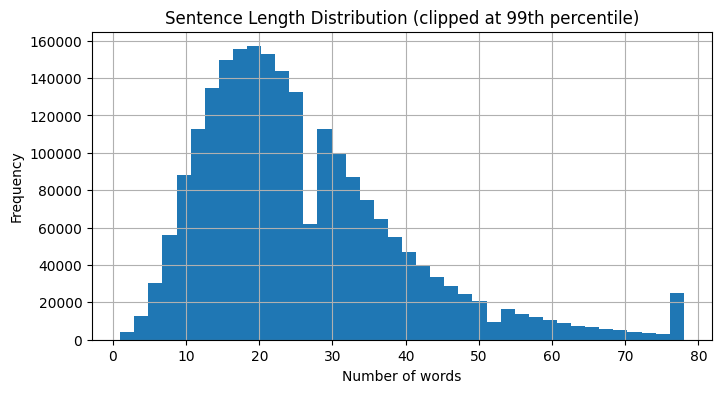

In [30]:
plt.figure(figsize=(8, 4))
train_df["n_words"].clip(upper=train_df["n_words"].quantile(0.99)).hist(bins=40)
plt.title("Sentence Length Distribution (clipped at 99th percentile)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

### Feasibility Interpretation

These checks confirm that:

- every rhetorical label has enough observations for balanced sampling,
- sentence lengths are moderate enough for standard TF-IDF vectorization,
- and the planned methods can operate on realistic subsets without requiring aggressive truncation or filtering.

This strengthens the feasibility of both clustering and retrieval experiments.

In [31]:
# Build a moderate sample for vectorization diagnostics
vectorization_sample = (
    train_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 2000), random_state=42))
    .reset_index(drop=True)
)

vectorization_sample.shape

(10000, 7)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_diag = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
)

X_diag = tfidf_diag.fit_transform(vectorization_sample["text"])

diag_summary = pd.DataFrame(
    {
        "n_documents": [X_diag.shape[0]],
        "n_features": [X_diag.shape[1]],
        "matrix_density": [X_diag.nnz / (X_diag.shape[0] * X_diag.shape[1])],
        "avg_nonzero_features_per_doc": [X_diag.nnz / X_diag.shape[0]],
    }
)

diag_summary

,n_documents,n_features,matrix_density,avg_nonzero_features_per_doc
0,10000,10000,0.001377,13.7686


### Why this diagnostic matters

TF-IDF is appropriate only if the representation remains sparse but informative.

This diagnostic checks:

- the dimensionality of the lexical feature space,
- the sparsity of the resulting matrix,
- and the average number of active features per sentence.

A sparse but non-degenerate matrix supports the use of TF-IDF for both clustering and retrieval.

### Initial Method Run: Clustering Feasibility Across Multiple `k`

A single clustering run shows that the pipeline executes, but it is also useful to verify that the method behaves sensibly across a small range of cluster counts.

This is not final tuning. It is only an early feasibility check to confirm that:

- the clustering pipeline is stable,
- silhouette scores are computable,
- and the chosen starting value of `k=5` is reasonable because the dataset contains five rhetorical labels.

In [33]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# Use a manageable sample for feasibility testing
cluster_sample = vectorization_sample.sample(min(len(vectorization_sample), 5000), random_state=42)
X_cluster = tfidf_diag.fit_transform(cluster_sample["text"])

k_results = []
for k in [4, 5, 6, 8]:
    model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024, n_init=10)
    cluster_labels = model.fit_predict(X_cluster)

    sil = silhouette_score(
        X_cluster,
        cluster_labels,
        sample_size=min(2000, X_cluster.shape[0]),
        random_state=42,
    )

    k_results.append(
        {
            "k": k,
            "silhouette_score": sil,
            "unique_clusters_found": len(set(cluster_labels)),
        }
    )

k_results_df = pd.DataFrame(k_results)
k_results_df

,k,silhouette_score,unique_clusters_found
0,4,0.002107,4
1,5,0.003043,5
2,6,0.002793,6
3,8,0.004438,8


### Feasibility Interpretation

This preliminary experiment confirms that MiniBatchKMeans runs successfully on TF-IDF sentence vectors and produces stable partitions across several plausible values of `k`.

This supports the decision to use clustering as a core course-method component in the final project.

### Initial Method Run: Retrieval Sanity Check

Because one of the research questions concerns retrieval behavior, I also perform a small retrieval sanity check.

The purpose of this step is not final evaluation, but to verify that:

- the TF-IDF retrieval pipeline is working end-to-end,
- query results are interpretable,
- and the planned qualitative case-study analysis is practical.

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

retrieval_sample = vectorization_sample.copy().reset_index(drop=True)
retrieval_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
)
X_retrieval = retrieval_vectorizer.fit_transform(retrieval_sample["text"])

def retrieve_top_k(query: str, vectorizer, matrix, df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    q_vec = vectorizer.transform([query])
    sims = cosine_similarity(q_vec, matrix).ravel()
    top_idx = sims.argsort()[::-1][:k]

    results = df.iloc[top_idx][["label", "text"]].copy()
    results["score"] = sims[top_idx]
    return results[["score", "label", "text"]]

retrieve_top_k("randomized controlled trial treatment outcome", retrieval_vectorizer, X_retrieval, retrieval_sample, k=5)

,score,label,text
5720,0.733301,METHODS,"Randomized , controlled trial ."
4036,0.733301,METHODS,A randomized controlled trial .
4255,0.733301,METHODS,Randomized controlled trial .
4906,0.733301,METHODS,Randomized controlled trial .
1705,0.684746,BACKGROUND,There has been no randomized controlled trial ...


### Feasibility Interpretation

This sanity check confirms that the retrieval pipeline can already surface plausible biomedical sentences for a query.

In [35]:
# Lightweight non-trivial checks for the feasibility pipeline
assert label_support["count"].min() > 0, "At least one label has no support."
assert X_diag.shape[0] == len(vectorization_sample), "Row count mismatch in TF-IDF matrix."
assert X_diag.shape[1] > 100, "TF-IDF feature space seems unexpectedly small."
assert k_results_df["unique_clusters_found"].min() >= 4, "Clustering did not produce enough distinct groups."

## Methodological planning

### Course-method plan
1. **TF-IDF lexical representation**
2. **MiniBatchKMeans clustering**
3. **Cluster interpretability**
   - top terms
   - dominant labels
   - representative examples
4. **Label-sensitive subgroup analysis**
   - compare behavior across BACKGROUND / METHODS / RESULTS / CONCLUSIONS

### External-method plan
1. **Sentence-BERT embeddings**
2. **Hybrid lexical + semantic retrieval scoring**
3. Semantic coherence analysis for clusters or retrieval outputs

### Baselines
- lexical TF-IDF retrieval and clustering
- cheap dense baseline via LSA/TruncatedSVD
- semantic representation compared against lexical baseline
- hybrid representation compared against both

### Evaluation plan
- **RQ1:** silhouette score, cluster purity, interpretability
- **RQ2:** per-label purity, label concentration, qualitative error patterns
- **RQ3:** retrieval case studies, thematic coherence, lexical-vs-semantic-vs-hybrid comparison


## Why these algorithmic choices are justified

- **TF-IDF** is the right lexical baseline because it is standard, transparent, and interpretable.
- **MiniBatchKMeans** is justified by scale and simplicity.
- **Balanced sampling** is justified for early planning because it reduces misleading dominance by frequent labels.
- **Sentence-BERT** is justified as the external semantic method because the central project question explicitly concerns semantic vs lexical representations.
- **Hybrid scoring** is justified because the motivating problem is not merely semantic similarity, but the tradeoff between exact terminology and conceptual meaning.


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans

sample_df = train_df.sample(n=5000, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_sample = vectorizer.fit_transform(sample_df["text"])

kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_sample)

print("Sample clustering completed. Unique clusters:", set(labels))

Sample clustering completed. Unique clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}


### Initial Method Feasibility Check

A small-scale clustering experiment was performed on a sampled subset of the data.

This confirms:
- TF-IDF vectorization is computationally feasible
- MiniBatchKMeans scales well to this dataset
- The pipeline can be executed end-to-end

This validates that the proposed methodology is practical within the course constraints.

## Collaboration Declaration

1. **Collaborators:** The idea was discussed with Professor Caverlee and his feedback was incorporated while finalising the project idea and direction.

2. **Web Sources:**  
- PubMed RCT Dataset: https://github.com/Franck-Dernoncourt/pubmed-rct  
- scikit-learn documentation: https://scikit-learn.org/stable/  
- pandas documentation: https://pandas.pydata.org/docs/  
- matplotlib documentation: https://matplotlib.org/stable/  
- sentence-transformers documentation: https://www.sbert.net/  

3. **AI Tools:** ChatGPT was used during this checkpoint.
After feedback from Prof. Cav, it was used to explore evaluation approaches for retrieval using available signals (e.g., label alignment and qualitative comparison). It also helped clarify usage of tools like `TfidfVectorizer`, `MiniBatchKMeans`.

4. **Papers / Citations used:**  
   - Dernoncourt, F. and Lee, J. Y. *PubMed 200k RCT: a Dataset for Sequential Sentence Classification in Medical Abstracts.* IJCNLP 2017.  
   - Reimers, N. and Gurevych, I. *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* EMNLP-IJCNLP 2019.